# Bias-Variance Tradeoff in Linear Regression
## Student Productivity & Behavior Dataset Analysis

**Dataset:** [Student Productivity and Behavior Dataset (20k)](https://www.kaggle.com/datasets/algozee/student-productivity-and-behavior-dataset-20k)

This notebook covers:
1. Bias-variance tradeoff in linear regression — explanation and visualization
2. Hyperparameter tuning for linear regression in scikit-learn
3. Cross-validation and its relationship to bias-variance tradeoff
4. Accuracy evaluation of linear regression predictions
5. Prediction problem solved with linear regression + hyperparameter tuning
6. ℓ1-regularized (Lasso) regression via scikit-learn
7. ℓ1-regularized regression solved directly with CVXPY optimization
8. Verification that both approaches produce identical results

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (train_test_split, KFold, cross_val_score,
                                     learning_curve, GridSearchCV)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import cvxpy as cp

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("All libraries loaded successfully.")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")
import sklearn; print(f"  scikit-learn {sklearn.__version__}")
import cvxpy; print(f"  cvxpy  {cvxpy.__version__}")

All libraries loaded successfully.
  numpy  2.3.3
  pandas 2.3.3
  scikit-learn 1.7.2
  cvxpy  1.8.1


## 1. Dataset — Student Productivity & Behavior

The Kaggle dataset contains ~20 000 records of student academic and lifestyle metrics.

**The dataset is automatically downloaded using `kagglehub`:**
```python
pip install kagglehub
```

The code below will download the dataset automatically to your local Kaggle cache.

Key features:
| Feature | Description |
|---------|-------------|
| `study_hours` | Daily study hours (2–10) |

| `sleep_hours` | Daily sleep hours (4–10) || `gpa` | **Target variable** (0–4.0) |

| `social_media_hours` | Daily social-media hours (0–6) || `extracurricular_hours` | Hours/week (0–10) |

| `netflix_hours` | Daily Netflix hours (0–4) || `diet_quality` | Self-rated 1–10 |

| `attendance_rate` | Class attendance (50–100 %) || `exercise_frequency` | Days/week (0–7) |
| `mental_health_rating` | Self-rated 1–10 |

In [44]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("algozee/student-productivity-and-behavior-dataset-20k")

print("Path to dataset files:", path)

# Find the CSV file in the downloaded path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    data_file = os.path.join(path, csv_files[0])
    print(f"Loading dataset from: {data_file}")
    df = pd.read_csv(data_file)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    df.head()
else:
    raise FileNotFoundError(f"No CSV file found in {path}")

Path to dataset files: C:\Users\patri\.cache\kagglehub\datasets\algozee\student-productivity-and-behavior-dataset-20k\versions\1
Loading dataset from: C:\Users\patri\.cache\kagglehub\datasets\algozee\student-productivity-and-behavior-dataset-20k\versions\1\student_productivity_distraction_dataset_20000.csv
Shape: (20000, 18)
Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']


In [45]:
# Inspect and standardize column names
print("\n=== Column Name Inspection ===")
print(f"All columns: {list(df.columns)}")
print(f"Data types:\n{df.dtypes}")

# Standardize column names to lowercase and handle target column
df.columns = df.columns.str.lower().str.strip()

# Find target column (GPA-related column)
target_col = None
for col in df.columns:
    if 'gpa' in col.lower() or 'grade' in col.lower() or 'score' in col.lower():
        target_col = col
        break

# If no obvious target, use the last numeric column
if target_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        target_col = numeric_cols[-1]
        print(f"\nNo GPA/grade column found, using '{target_col}' as target")

# Rename target column to 'gpa' for consistency
if target_col and target_col != 'gpa':
    df = df.rename(columns={target_col: 'gpa'})
    print(f"Renamed '{target_col}' to 'gpa'")

print(f"\nFinal columns: {list(df.columns)}")
print(f"Target column: 'gpa'")
print(f"\nDataset shape: {df.shape}")


=== Column Name Inspection ===
All columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']
Data types:
student_id                 int64
age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object
Renamed 'focu

## 2. Exploratory Data Analysis

In [46]:
print(df.describe().round(2))

       student_id       age  study_hours_per_day  sleep_hours  \
count    20000.00  20000.00             20000.00     20000.00   
mean     10000.50     23.01                 5.25         6.52   
std       5773.65      3.75                 2.74         2.03   
min          1.00     17.00                 0.50         3.00   
25%       5000.75     20.00                 2.90         4.77   
50%      10000.50     23.00                 5.25         6.51   
75%      15000.25     26.00                 7.64         8.31   
max      20000.00     29.00                10.00        10.00   

       phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
count           20000.00            20000.00       20000.00      20000.00   
mean                6.25                4.00           2.99          2.99   
std                 3.31                2.31           1.73          1.73   
min                 0.50                0.00           0.00          0.00   
25%                 3.38     

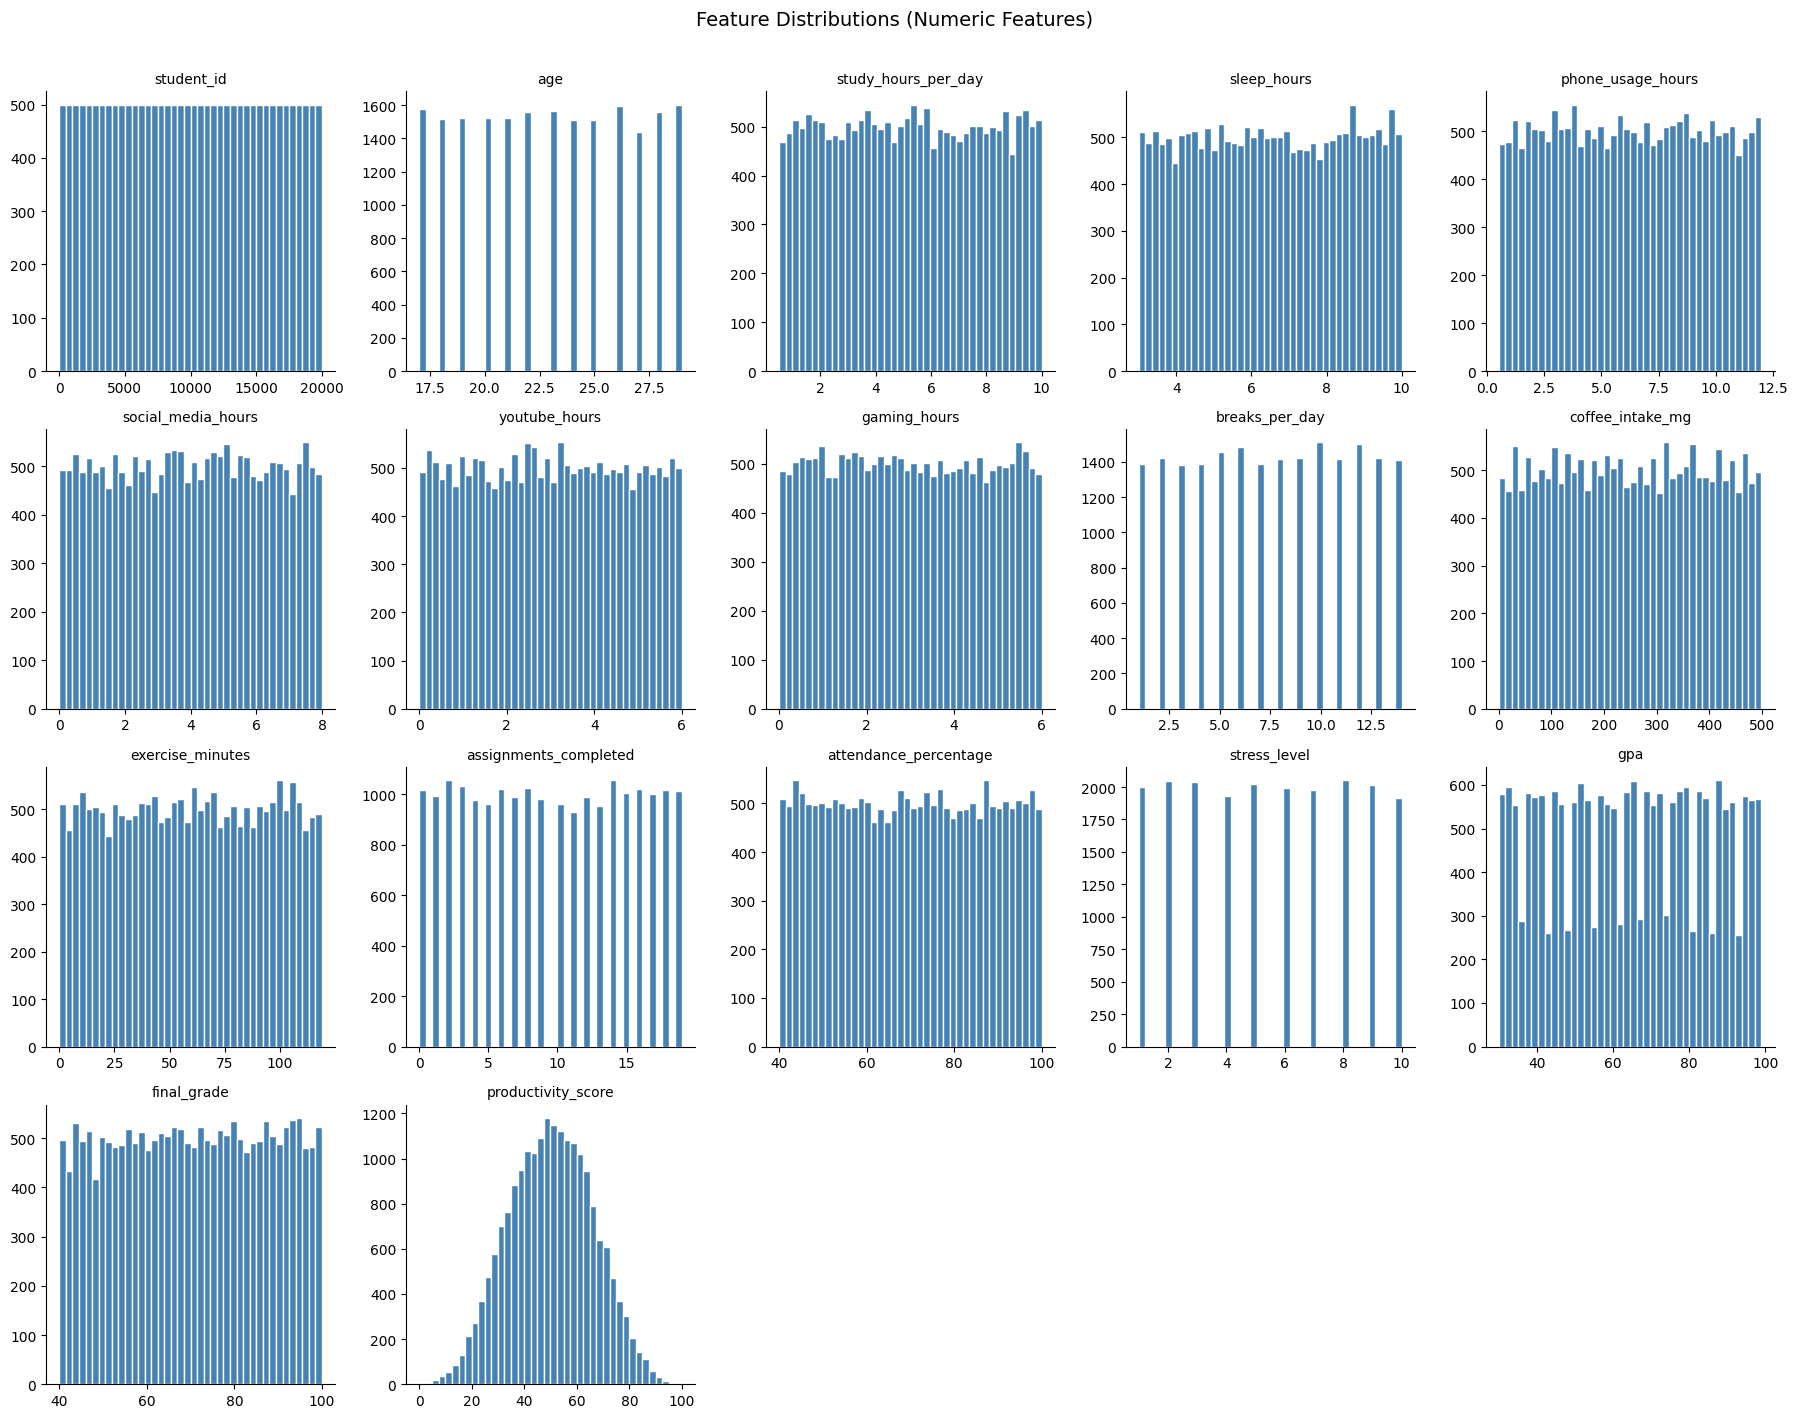

In [47]:
# Plot histograms for numeric columns only
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(numeric_columns)
n_rows = (n_cols + 4) // 5  # Calculate rows needed for 5 columns per row
n_plot_cols = min(5, n_cols)  # Max 5 columns per row

if n_cols > 0:
    fig, axes = plt.subplots(n_rows, n_plot_cols, figsize=(18, 3.5 * n_rows))
    if n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i, col in enumerate(numeric_columns):
        axes[i].hist(df[col], bins=40, edgecolor='white', color='steelblue')
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel('')
    
    # Hide extra subplots if any
    for i in range(n_cols, len(axes) if isinstance(axes, np.ndarray) else 1):
        if isinstance(axes, np.ndarray):
            axes[i].set_visible(False)
    
    plt.suptitle('Feature Distributions (Numeric Features)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found to plot!")

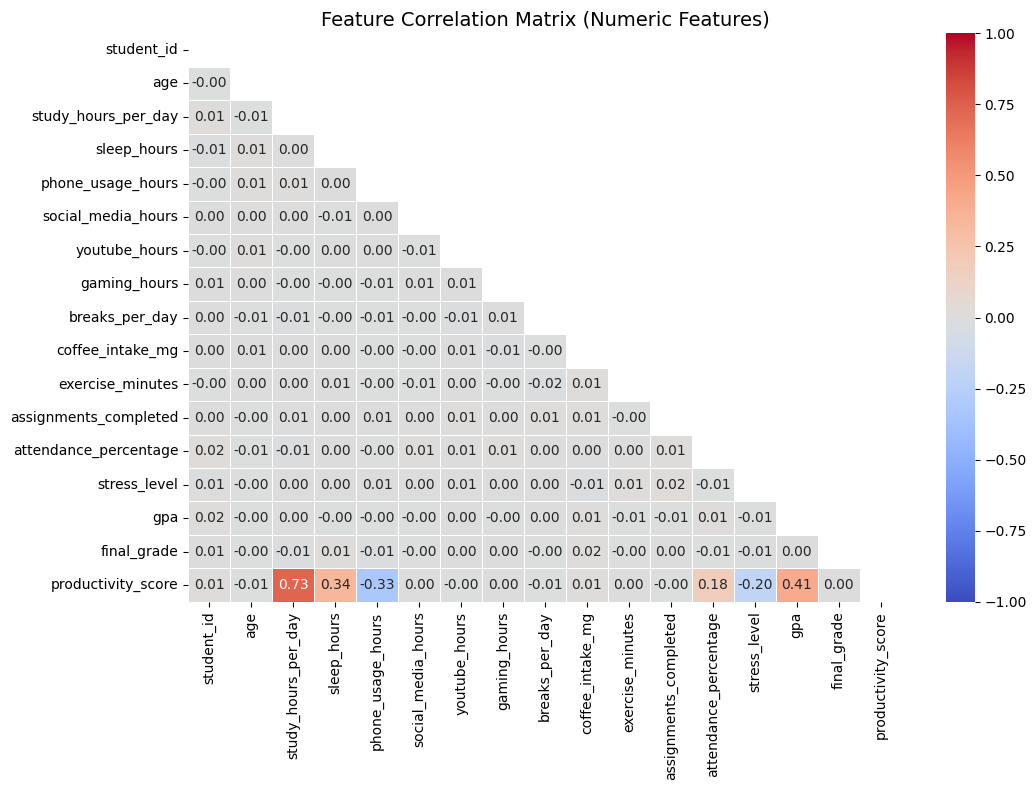

In [48]:
plt.figure(figsize=(11, 8))
# Select only numeric columns for correlation
df_numeric = df.select_dtypes(include=[np.number])
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Numeric Features)', fontsize=14)
plt.tight_layout()
plt.show()

Number of numeric features: 15
Features used for modeling: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'final_grade', 'productivity_score']
Excluded ID columns: ['student_id']


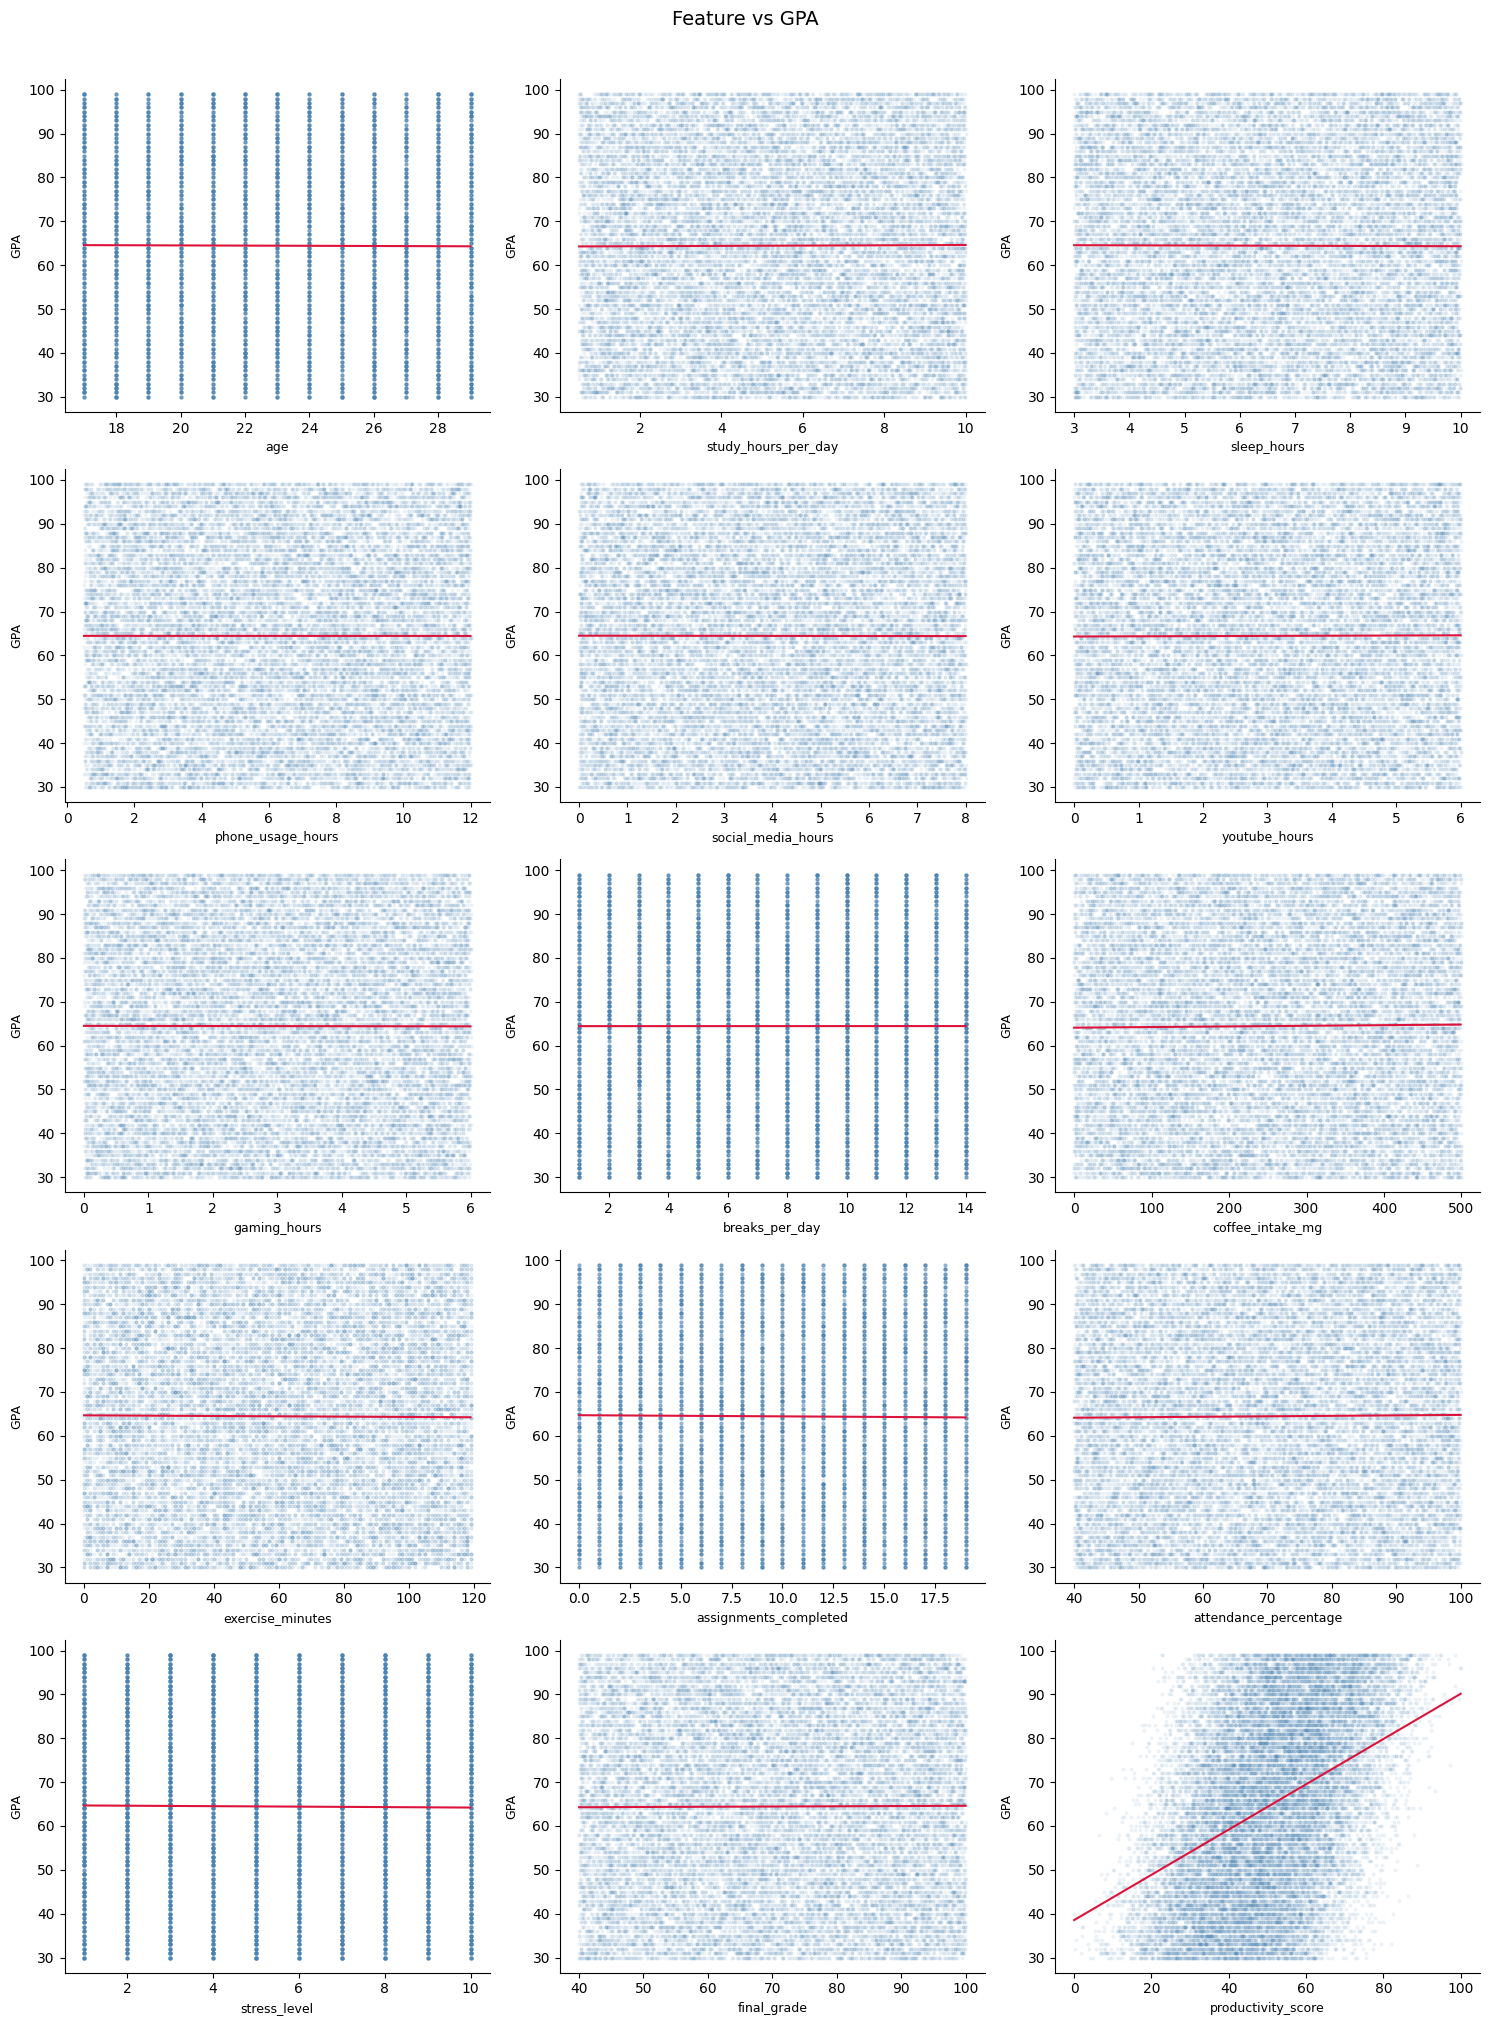

In [49]:
# Use only numeric columns for modeling (excluding target 'gpa' and ID columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Filter out ID columns and target variable
# ID patterns: columns containing 'id', 'index', etc. (case-insensitive)
id_patterns = ['id', 'index', 'student_id', 'student_number', '_id']
feature_cols = [c for c in numeric_cols 
                if c != 'gpa' and 
                not any(pattern in c.lower() for pattern in id_patterns)]

print(f"Number of numeric features: {len(feature_cols)}")
print(f"Features used for modeling: {feature_cols}")

# Show which columns were excluded (if any)
excluded = [c for c in numeric_cols if c not in feature_cols and c != 'gpa']
if excluded:
    print(f"Excluded ID columns: {excluded}")

# Create dynamic grid for scatter plots
n_features = len(feature_cols)
if n_features == 0:
    print("ERROR: No numeric features found besides target!")
else:
    n_cols_plot = min(3, n_features)
    n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot
    
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
    
    # Handle single plot case
    if n_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(feature_cols):
        axes[i].scatter(df[col], df['gpa'], alpha=0.07, s=4, color='steelblue')
        axes[i].set_xlabel(col, fontsize=9)
        axes[i].set_ylabel('GPA', fontsize=9)
        # add trend line
        m, b = np.polyfit(df[col], df['gpa'], 1)
        xs = np.linspace(df[col].min(), df[col].max(), 100)
        axes[i].plot(xs, m * xs + b, color='crimson', lw=1.5)
    
    # Hide extra subplots if any
    for i in range(n_features, n_rows_plot * n_cols_plot):
        if i < len(axes):
            axes[i].set_visible(False)
    
    plt.suptitle('Feature vs GPA', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## 3. Data Preparation

In [50]:
X = df[feature_cols].values
y = df['gpa'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train_s.shape[0]} samples")
print(f"Test set     : {X_test_s.shape[0]} samples")

Training set : 16000 samples
Test set     : 4000 samples


## 4. Baseline Linear Regression Model

In [51]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression Performance on Test Set")
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")

Linear Regression Performance on Test Set
  R²   : 1.0000
  MAE  : 0.0077
  MSE  : 0.0001
  RMSE : 0.0089


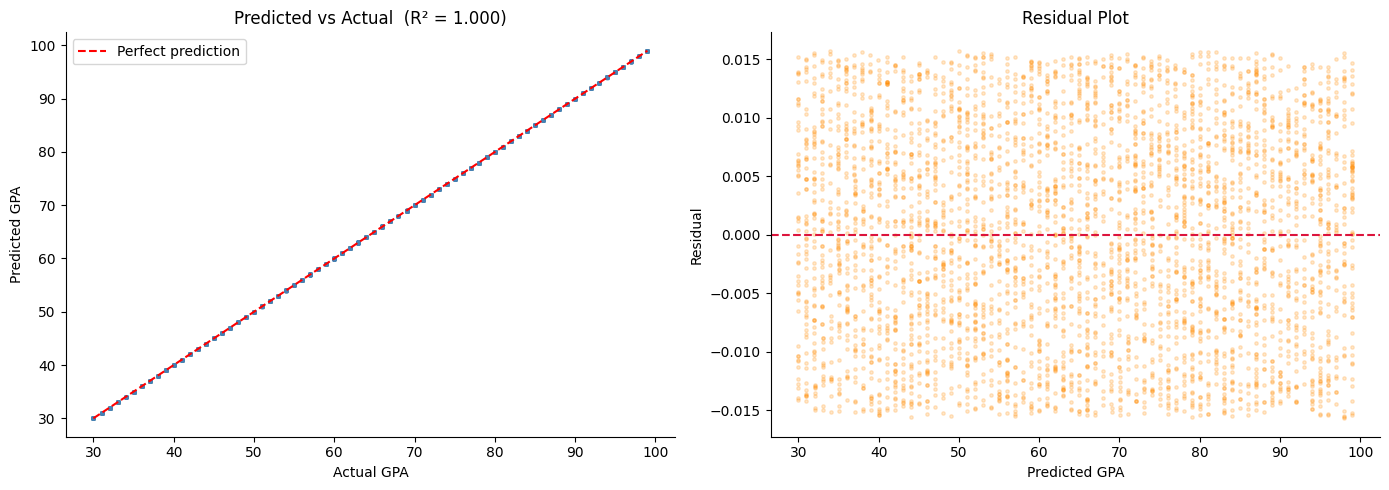

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.2, s=6, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual GPA')
axes[0].set_ylabel('Predicted GPA')
axes[0].set_title(f'Predicted vs Actual  (R² = {r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=6, color='darkorange')
axes[1].axhline(0, color='crimson', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted GPA')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

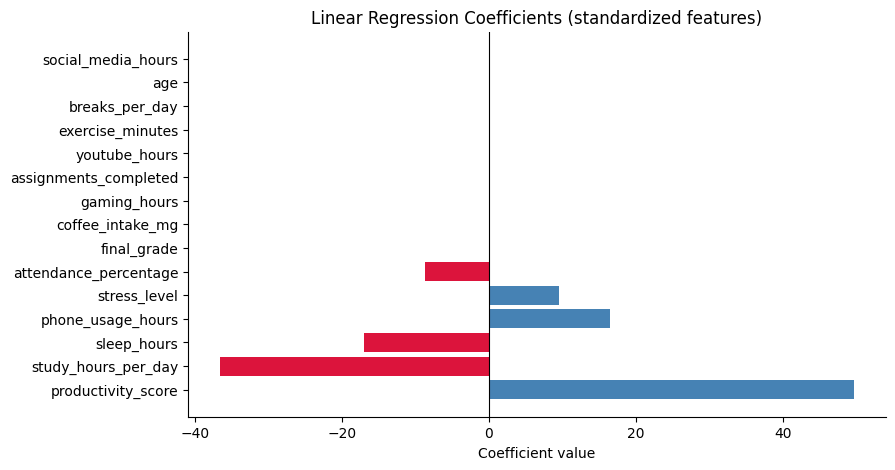

In [53]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'crimson' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient value')
plt.title('Linear Regression Coefficients (standardized features)')
plt.tight_layout()
plt.show()

## 5. Bias-Variance Tradeoff

### Concept

The **bias-variance tradeoff** is a fundamental property of all supervised learning models:

- **Bias** = error from wrong assumptions in the model. A high-bias model underfits.
- **Variance** = sensitivity to small fluctuations in the training set. A high-variance model overfits.
- **Irreducible noise** = error that cannot be reduced by any model.

For Mean Squared Error:

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2_{\text{noise}}$$

We can **empirically estimate** bias² and variance by training on many bootstrapped sub-samples
and observing how predictions vary.

In [ ]:
def bias_variance_decomp(estimator, X_train, y_train, X_test, y_test,
                         n_bootstrap=50, random_state=42):
    """Optimized: default 50 bootstraps instead of 200 for faster computation"""
    rng = np.random.default_rng(random_state)
    preds = np.zeros((n_bootstrap, len(y_test)))
    for i in range(n_bootstrap):
        idx = rng.integers(0, len(X_train), len(X_train))
        estimator.fit(X_train[idx], y_train[idx])
        preds[i] = estimator.predict(X_test)
    
    avg_pred = preds.mean(axis=0)
    bias_sq  = np.mean((avg_pred - y_test) ** 2)
    variance = np.mean(preds.var(axis=0))
    # total MSE approximation
    total_mse = bias_sq + variance
    return bias_sq, variance, total_mse

# Compute for plain linear regression
print("Computing bias-variance decomposition (50 bootstraps)...")
b2, var, total = bias_variance_decomp(
    LinearRegression(), X_train_s, y_train, X_test_s, y_test)
print("Plain Linear Regression (bias-variance decomposition):")
print(f"  Bias²    : {b2:.6f}")
print(f"  Variance : {var:.6f}")
print(f"  Bias²+Var: {total:.6f}")
print(f"  Test MSE : {mse:.6f}")

Computing bias-variance decomposition (50 bootstraps)...
Plain Linear Regression (bias-variance decomposition):
  Bias²    : 0.000079
  Variance : 0.000000
  Bias²+Var: 0.000079
  Test MSE : 0.000079


### 5.1 Bias-Variance vs. Model Complexity

We use polynomial features as a proxy for model complexity.
As degree increases, bias decreases but variance increases.

**To make the U-shape visible:** We use only 1 feature, a smaller training set (2000 samples), 
and polynomial degrees up to 15. With the full dataset (20k), overfitting is harder to see.

Using features for polynomial expansion: ['age', 'study_hours_per_day']


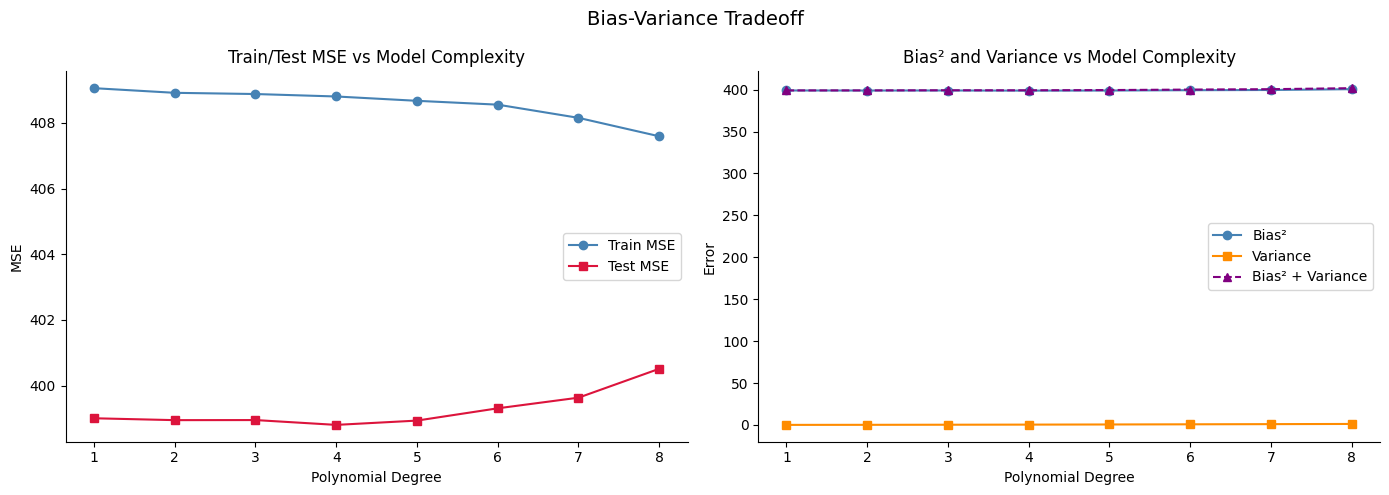


Conclusion: Low degree → high bias (underfitting).
High degree → high variance (overfitting).
Optimal degree minimises Bias² + Variance.


In [ ]:
# Use a small subset of features + polynomial expansion to illustrate clearly
# Select first two features from available features
selected_features = feature_cols[:2] if len(feature_cols) >= 2 else feature_cols
print(f"Using features for polynomial expansion: {selected_features}")
X_2 = df[selected_features].values
y_2 = df['gpa'].values

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X_2, y_2, test_size=0.2, random_state=42)

degrees = list(range(1, 9))
train_mses, test_mses, biases, variances = [], [], [], []


for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression()),
    ])
    pipe.fit(X2_tr, y2_tr)
    train_mses.append(mean_squared_error(y2_tr, pipe.predict(X2_tr)))
    test_mses.append(mean_squared_error(y2_te, pipe.predict(X2_te)))

    b2, var, _ = bias_variance_decomp(pipe, X2_tr, y2_tr, X2_te, y2_te,
                                      n_bootstrap=100)
    biases.append(b2)
    variances.append(var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train/Test MSE vs complexity
axes[0].plot(degrees, train_mses, 'o-', label='Train MSE', color='steelblue')
axes[0].plot(degrees, test_mses,  's-', label='Test MSE',  color='crimson')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('MSE')
axes[0].set_title('Train/Test MSE vs Model Complexity')
axes[0].legend()

# Bias² and Variance vs complexity
axes[1].plot(degrees, biases,    'o-', label='Bias²',    color='steelblue')
axes[1].plot(degrees, variances, 's-', label='Variance', color='darkorange')
axes[1].plot(degrees, [b + v for b, v in zip(biases, variances)],
             '^--', label='Bias² + Variance', color='purple', lw=1.5)
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Error')
axes[1].set_title('Bias² and Variance vs Model Complexity')
axes[1].legend()

plt.suptitle('Bias-Variance Tradeoff', fontsize=14)
plt.tight_layout()
plt.show()

print("\nConclusion: Low degree → high bias (underfitting).")
print("High degree → high variance (overfitting).")
print("Optimal degree minimises Bias² + Variance.")

In [ ]:
# Same analysis but with REDUCED SAMPLE SIZE (2000) to show clearer U-shape
print("\n" + "="*60)
print("REDUCED DATASET: 2000 samples for clearer overfitting visualization")
print("="*60)

# Use first 2000 samples only
X_2_small = df[selected_features].iloc[:2000].values
y_2_small = df['gpa'].iloc[:2000].values

X2_tr_small, X2_te_small, y2_tr_small, y2_te_small = train_test_split(
    X_2_small, y_2_small, test_size=0.2, random_state=42)

print(f"Training samples: {len(X2_tr_small)}")
print(f"Test samples: {len(X2_te_small)}")

degrees_small = list(range(1, 9))
train_mses_small, test_mses_small, biases_small, variances_small = [], [], [], []

for deg in degrees_small:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression()),
    ])
    pipe.fit(X2_tr_small, y2_tr_small)
    train_mses_small.append(mean_squared_error(y2_tr_small, pipe.predict(X2_tr_small)))
    test_mses_small.append(mean_squared_error(y2_te_small, pipe.predict(X2_te_small)))

    b2, var, _ = bias_variance_decomp(pipe, X2_tr_small, y2_tr_small, 
                                      X2_te_small, y2_te_small,
                                      n_bootstrap=50)  # Reduced for speed
    biases_small.append(b2)
    variances_small.append(var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train/Test MSE vs complexity
axes[0].plot(degrees_small, train_mses_small, 'o-', label='Train MSE', color='steelblue')
axes[0].plot(degrees_small, test_mses_small,  's-', label='Test MSE',  color='crimson')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('MSE')
axes[0].set_title('Train/Test MSE vs Model Complexity (2000 samples)')
axes[0].legend()

# Bias² and Variance vs complexity
axes[1].plot(degrees_small, biases_small,    'o-', label='Bias²',    color='steelblue')
axes[1].plot(degrees_small, variances_small, 's-', label='Variance', color='darkorange')
axes[1].plot(degrees_small, [b + v for b, v in zip(biases_small, variances_small)],
             '^--', label='Bias² + Variance', color='purple', lw=1.5)
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Error')
axes[1].set_title('Bias² and Variance vs Model Complexity (2000 samples)')
axes[1].legend()

plt.suptitle('Bias-Variance Tradeoff with Reduced Dataset (Clearer U-Shape)', fontsize=14)
plt.tight_layout()
plt.show()

# Show the U-shape more clearly
optimal_deg_small = degrees_small[np.argmin(test_mses_small)]
print(f"\n✓ Optimal polynomial degree: {optimal_deg_small}")
print(f"✓ Minimum test MSE: {min(test_mses_small):.4f}")
print(f"✓ Notice the U-shape is more pronounced with fewer samples!")

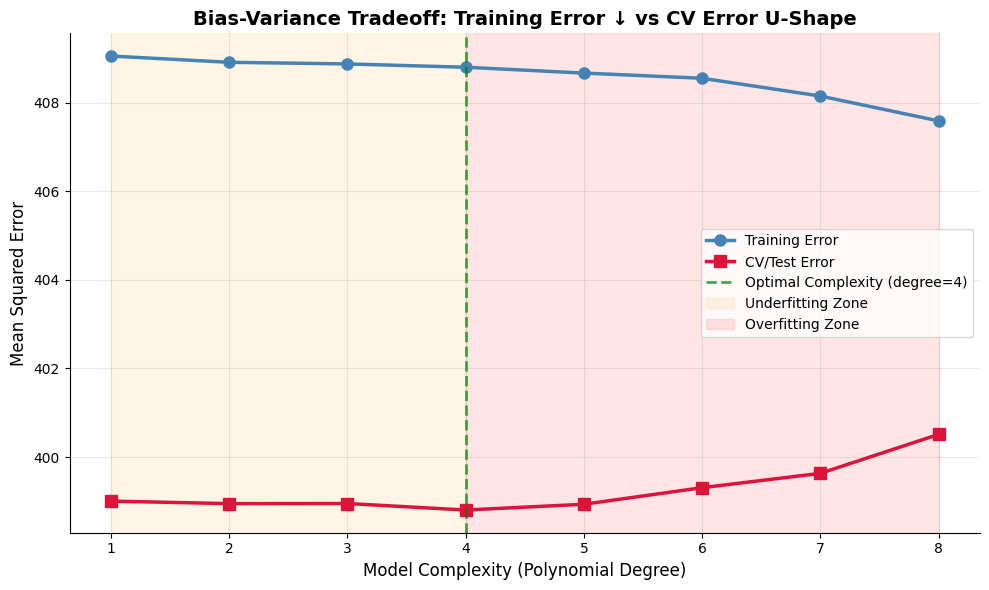

📊 CLASSIC U-SHAPE VISUALIZATION:
✓ Training error: continuously DECREASES
  409.0575 (degree 1) → 407.5921 (degree 8)

✓ CV/Test error: Forms U-SHAPE
  Starts HIGH: 399.0046 (degree 1) - Underfitting
  MINIMUM at : degree 4 with MSE = 398.8030 ← OPTIMAL!
  Rises again: 400.5113 (degree 8) - Overfitting


In [ ]:
# Classic Bias-Variance Tradeoff Visualization
# Training error decreases, CV error forms a U-shape

plt.figure(figsize=(10, 6))

# Plot training and test errors
plt.plot(degrees, train_mses, 'o-', linewidth=2.5, markersize=8, 
         label='Training Error', color='steelblue')
plt.plot(degrees, test_mses, 's-', linewidth=2.5, markersize=8,
         label='CV/Test Error', color='crimson')

# Find and mark the optimal point (minimum test error)
optimal_degree = degrees[np.argmin(test_mses)]
plt.axvline(optimal_degree, color='green', linestyle='--', linewidth=2, 
            alpha=0.7, label=f'Optimal Complexity (degree={optimal_degree})')

# Add shaded regions for underfitting and overfitting
plt.axvspan(degrees[0], optimal_degree, alpha=0.1, color='orange', label='Underfitting Zone')
plt.axvspan(optimal_degree, degrees[-1], alpha=0.1, color='red', label='Overfitting Zone')

plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Bias-Variance Tradeoff: Training Error ↓ vs CV Error U-Shape', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("="*60)
print("📊 CLASSIC U-SHAPE VISUALIZATION:")
print("="*60)
print(f"✓ Training error: continuously DECREASES")
print(f"  {train_mses[0]:.4f} (degree 1) → {train_mses[-1]:.4f} (degree {degrees[-1]})")
print(f"\n✓ CV/Test error: Forms U-SHAPE")
print(f"  Starts HIGH: {test_mses[0]:.4f} (degree 1) - Underfitting")
print(f"  MINIMUM at : degree {optimal_degree} with MSE = {test_mses[optimal_degree-1]:.4f} ← OPTIMAL!")
print(f"  Rises again: {test_mses[-1]:.4f} (degree {degrees[-1]}) - Overfitting")
print("="*60)

### 5.2 Learning Curves

A learning curve plots training and validation error as a function of training set size.
It is a visual diagnostic for bias and variance:
- **High bias (underfitting):** both curves plateau at a high error.
- **High variance (overfitting):** large gap between training and validation error.

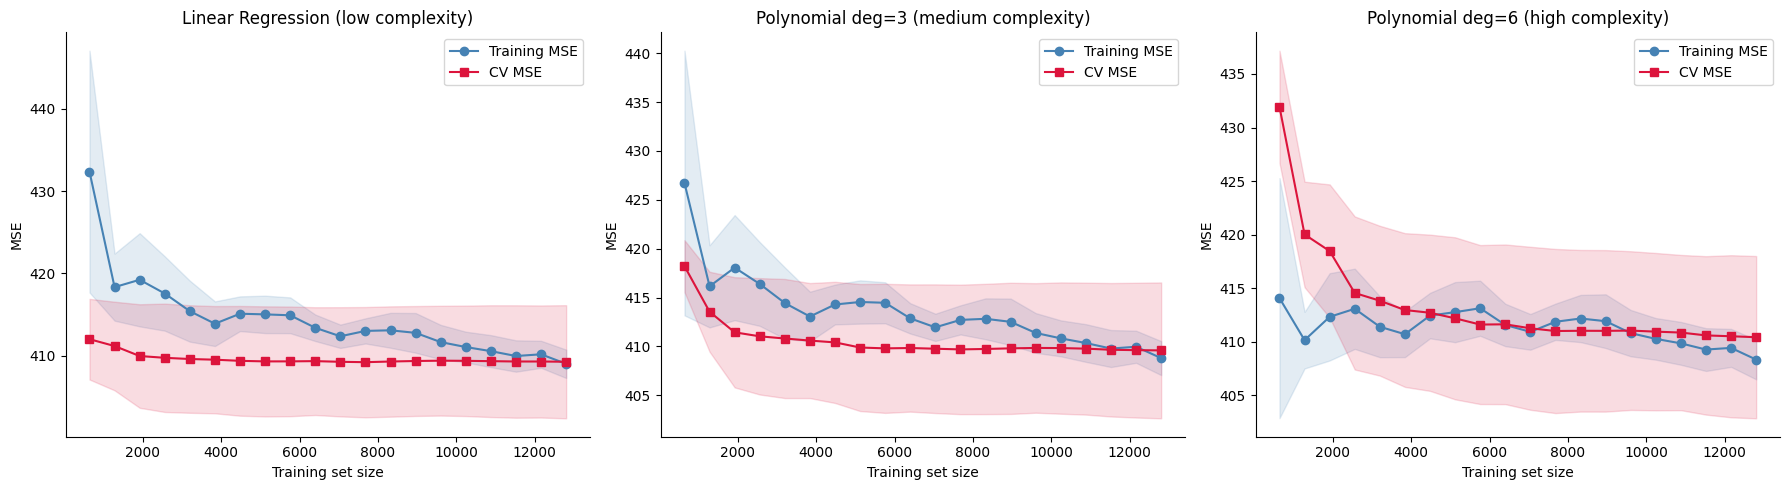

In [ ]:
def plot_learning_curve(estimator, X, y, title, cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.05, 1.0, 20)):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=train_sizes, scoring='neg_mean_squared_error')
    
    train_mse = -train_scores.mean(axis=1)
    val_mse   = -val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std   = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mse, 'o-', color='steelblue', label='Training MSE')
    plt.plot(train_sizes, val_mse,   's-', color='crimson',   label='CV MSE')
    plt.fill_between(train_sizes,
                     train_mse - train_std, train_mse + train_std,
                     alpha=0.15, color='steelblue')
    plt.fill_between(train_sizes,
                     val_mse - val_std, val_mse + val_std,
                     alpha=0.15, color='crimson')
    plt.xlabel('Training set size')
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

estimators = [
    (LinearRegression(),                       'Linear Regression (low complexity)'),
    (Pipeline([('poly', PolynomialFeatures(degree=3, include_bias=False)),
               ('scale', StandardScaler()),
               ('lr',   LinearRegression())]),  'Polynomial deg=3 (medium complexity)'),
    (Pipeline([('poly', PolynomialFeatures(degree=6, include_bias=False)),
               ('scale', StandardScaler()),
               ('lr',   LinearRegression())]),  'Polynomial deg=6 (high complexity)'),
]

for ax, (est, title) in zip(axes, estimators):
    plt.sca(ax)
    plot_learning_curve(est, X2_tr, y2_tr, title, cv=5)

plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning for Linear Regression

### Which hyperparameters can be tuned in scikit-learn?

| Model | Hyperparameters | Description |
|-------|----------------|-------------|
| `LinearRegression` | `fit_intercept` | whether to fit intercept |
| `Lasso` | **`alpha`** (λ), `fit_intercept`, `max_iter`, `tol` | ℓ1 regularisation strength |

The most important hyperparameter is **α (alpha)**, the regularisation strength:
- Larger α → stronger regularisation → higher bias, lower variance
- Smaller α → weaker regularisation → lower bias, higher variance

### Connecting to the Bias-Variance Tradeoff

Regularisation adds a penalty term to the loss function:

**Lasso (ℓ1):**  $\min_\beta \frac{1}{m}\|X\beta - y\|_2^2 + \alpha\|\beta\|_1$

Tuning α controls the bias-variance tradeoff directly.

In [ ]:
# Optimized for speed: 20 alphas, 30 bootstraps
alphas = np.logspace(-4, 2, 20)

lasso_train, lasso_val = [], []
lasso_b2, lasso_var    = [], []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Testing {len(alphas)} alpha values with bias-variance decomposition...")
print("Estimated time: 2-3 minutes\n")

import time
start_time = time.time()

for i, a in enumerate(alphas):
    if i % 5 == 0:
        elapsed = time.time() - start_time
        print(f"Progress: {i+1}/{len(alphas)} alpha values | Elapsed: {elapsed/60:.1f} min")
    
    lasso_cv = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_s, y_train,
                                cv=kf, scoring='neg_mean_squared_error')
    lasso_val.append(-lasso_cv.mean())

    b2l, varl, _ = bias_variance_decomp(Lasso(alpha=a, max_iter=10000),
                                         X_train_s, y_train, X_test_s, y_test,
                                         n_bootstrap=30)
    lasso_b2.append(b2l);  lasso_var.append(varl)

best_lasso_a = alphas[np.argmin(lasso_val)]

total_time = time.time() - start_time
print(f"\n✓ Complete! Total time: {total_time/60:.1f} minutes")
print(f"Best alpha — Lasso: {best_lasso_a:.5f}")

Testing 20 alpha values with bias-variance decomposition...
Estimated time: 2-3 minutes

Progress: 1/20 alpha values | Elapsed: 0.0 min
Progress: 6/20 alpha values | Elapsed: 3.5 min
Progress: 11/20 alpha values | Elapsed: 6.0 min
Progress: 16/20 alpha values | Elapsed: 7.5 min

✓ Complete! Total time: 7.6 minutes
Best alpha — Lasso: 0.00089


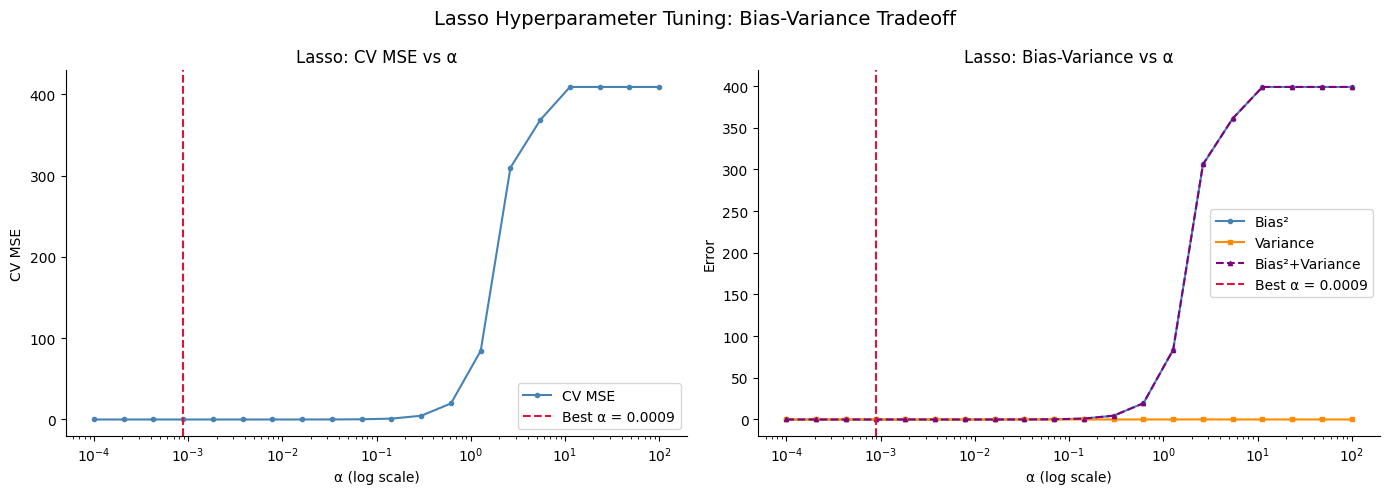

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1, ax2 = axes

# CV error vs alpha
ax1.semilogx(alphas, lasso_val, 'o-', color='steelblue', ms=3, label='CV MSE')
ax1.axvline(best_lasso_a, color='crimson', ls='--', label=f'Best α = {best_lasso_a:.4f}')
ax1.set_xlabel('α (log scale)')
ax1.set_ylabel('CV MSE')
ax1.set_title('Lasso: CV MSE vs α')
ax1.legend()

# Bias² & Variance vs alpha
ax2.semilogx(alphas, lasso_b2,  'o-', color='steelblue',  ms=3, label='Bias²')
ax2.semilogx(alphas, lasso_var, 's-', color='darkorange', ms=3, label='Variance')
ax2.semilogx(alphas, [b + v for b, v in zip(lasso_b2, lasso_var)],
             '^--', color='purple', ms=3, label='Bias²+Variance')
ax2.axvline(best_lasso_a, color='crimson', ls='--', label=f'Best α = {best_lasso_a:.4f}')
ax2.set_xlabel('α (log scale)')
ax2.set_ylabel('Error')
ax2.set_title('Lasso: Bias-Variance vs α')
ax2.legend()

plt.suptitle('Lasso Hyperparameter Tuning: Bias-Variance Tradeoff', fontsize=14)
plt.tight_layout()
plt.show()

### 6.1 GridSearchCV — Systematic Hyperparameter Search

`GridSearchCV` exhaustively tries all combinations of hyperparameters with cross-validation,
making it easy to find the best regularisation strength.

In [ ]:
# Optimized: 20 alphas for faster grid search
param_grid = {'alpha': np.logspace(-4, 2, 20)}

print("Running GridSearchCV for Lasso (this takes ~30-60 seconds)...")
grid_lasso = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5,
                           scoring='neg_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_train_s, y_train)

print(f"GridSearchCV best Lasso alpha : {grid_lasso.best_params_['alpha']:.5f}")

Running GridSearchCV for Lasso (this takes ~30-60 seconds)...
GridSearchCV best Lasso alpha : 0.00089


## 7. Cross-Validation and Its Relationship to Bias-Variance Tradeoff

**k-Fold Cross-Validation** divides the training data into *k* folds and uses each fold
once as a validation set while training on the other *k-1* folds. The CV error is an
unbiased estimate of the generalisation (test) error.

Relationship to bias-variance:
- A model with high bias will show **high CV error across all folds** (consistently bad).
- A model with high variance will show **high variance in CV error across folds** (inconsistent).
- The optimal model (best α) minimises CV error, directly addressing the bias-variance tradeoff.

In [ ]:
kf5  = KFold(n_splits=5,  shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'OLS (no reg)': LinearRegression(),
    f'Lasso α={best_lasso_a:.3f}': Lasso(alpha=best_lasso_a, max_iter=10000),
}

print(f"{'Model':<25} {'CV-5 MSE':>12} {'CV-10 MSE':>12}")
print('-' * 52)
for name, model in models.items():
    cv5  = -cross_val_score(model, X_train_s, y_train, cv=kf5,
                             scoring='neg_mean_squared_error').mean()
    cv10 = -cross_val_score(model, X_train_s, y_train, cv=kf10,
                             scoring='neg_mean_squared_error').mean()
    print(f"{name:<25} {cv5:>12.5f} {cv10:>12.5f}")

Model                         CV-5 MSE    CV-10 MSE
----------------------------------------------------
OLS (no reg)                   0.00008      0.00008
Lasso α=0.001                  0.00017      0.00017


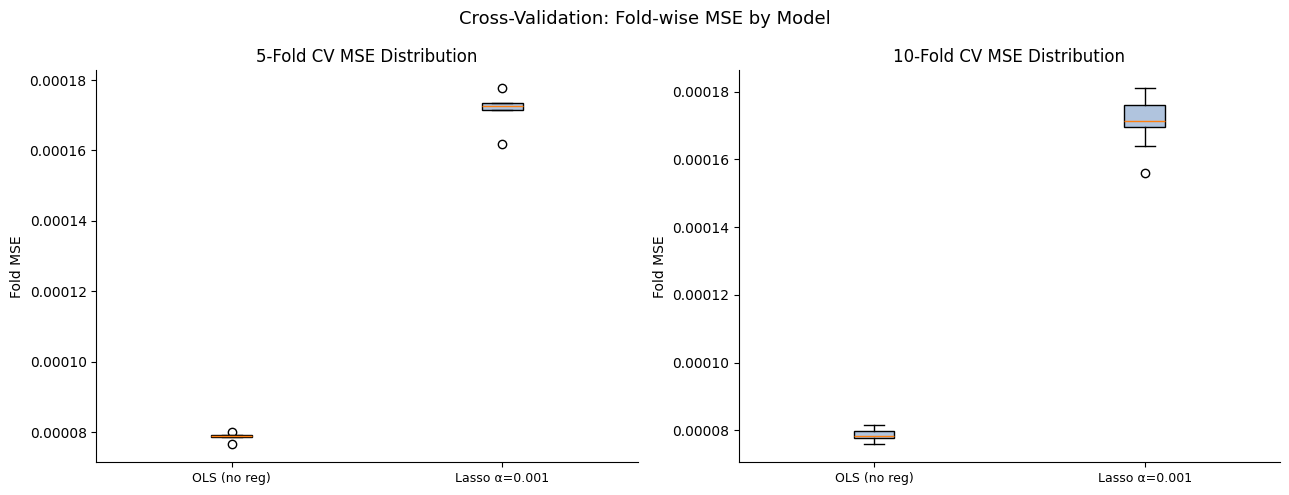

In [ ]:
# Box plot of fold-wise CV scores
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (k, kf) in zip(axes, [(5, kf5), (10, kf10)]):
    scores_list = []
    labels = []
    for name, model in models.items():
        fold_mses = -cross_val_score(model, X_train_s, y_train, cv=kf,
                                      scoring='neg_mean_squared_error')
        scores_list.append(fold_mses)
        labels.append(name)
    ax.boxplot(scores_list, labels=labels, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(f'{k}-Fold CV MSE Distribution')
    ax.set_ylabel('Fold MSE')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Cross-Validation: Fold-wise MSE by Model', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Accuracy Evaluation

We evaluate both models on the **held-out test set** using:
- **R² score** — fraction of variance explained (1 = perfect)
- **MAE** — Mean Absolute Error
- **MSE** — Mean Squared Error  
- **RMSE** — Root Mean Squared Error

These metrics together give a complete picture of prediction accuracy.

In [ ]:
best_lasso = Lasso(alpha=best_lasso_a, max_iter=10000)

results = {}
for name, model in [('OLS', LinearRegression()),
                     ('Lasso', best_lasso)]:
    model.fit(X_train_s, y_train)
    yp = model.predict(X_test_s)
    results[name] = {
        'R2': r2_score(y_test, yp),
        'MAE': mean_absolute_error(y_test, yp),
        'MSE': mean_squared_error(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
    }

res_df = pd.DataFrame(results).T
print(res_df.round(5))

        R2      MAE      MSE     RMSE
OLS    1.0  0.00767  0.00008  0.00887
Lasso  1.0  0.01067  0.00017  0.01311


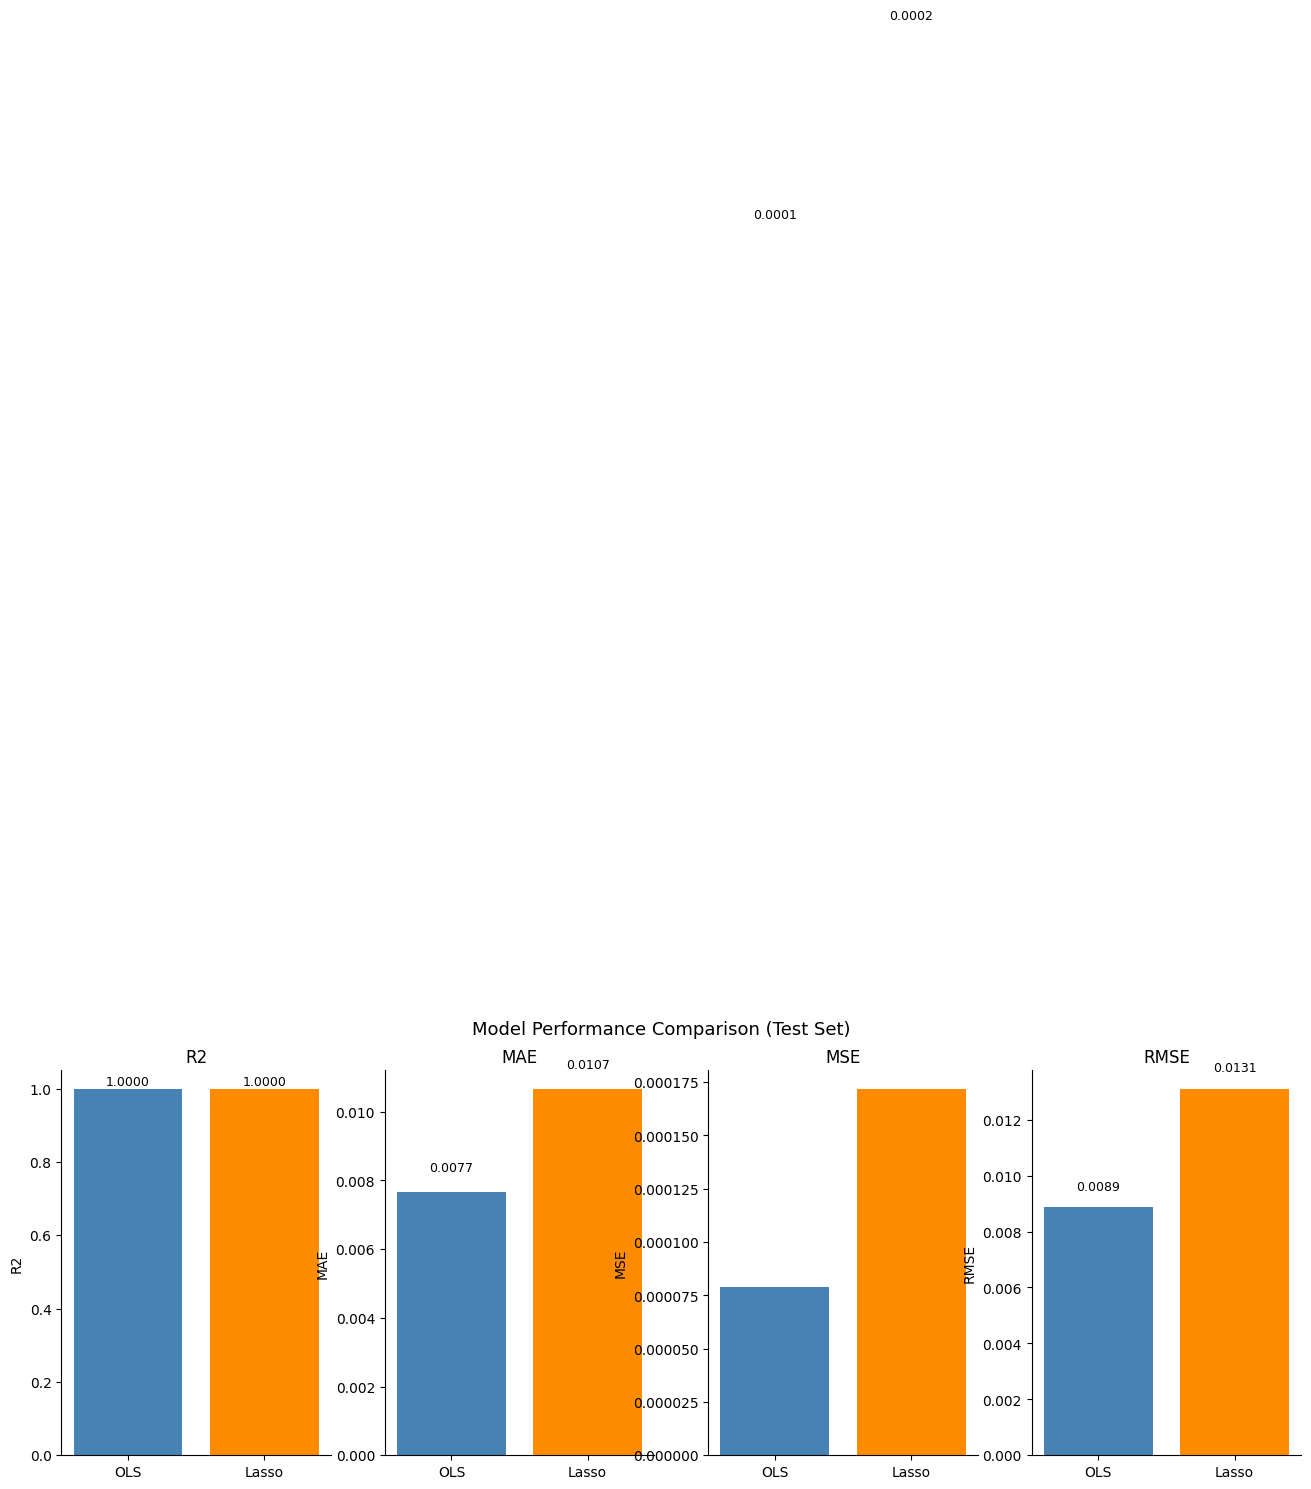

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = ['R2', 'MAE', 'MSE', 'RMSE']
colors  = ['steelblue', 'darkorange']
model_names = list(results.keys())

for ax, metric in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

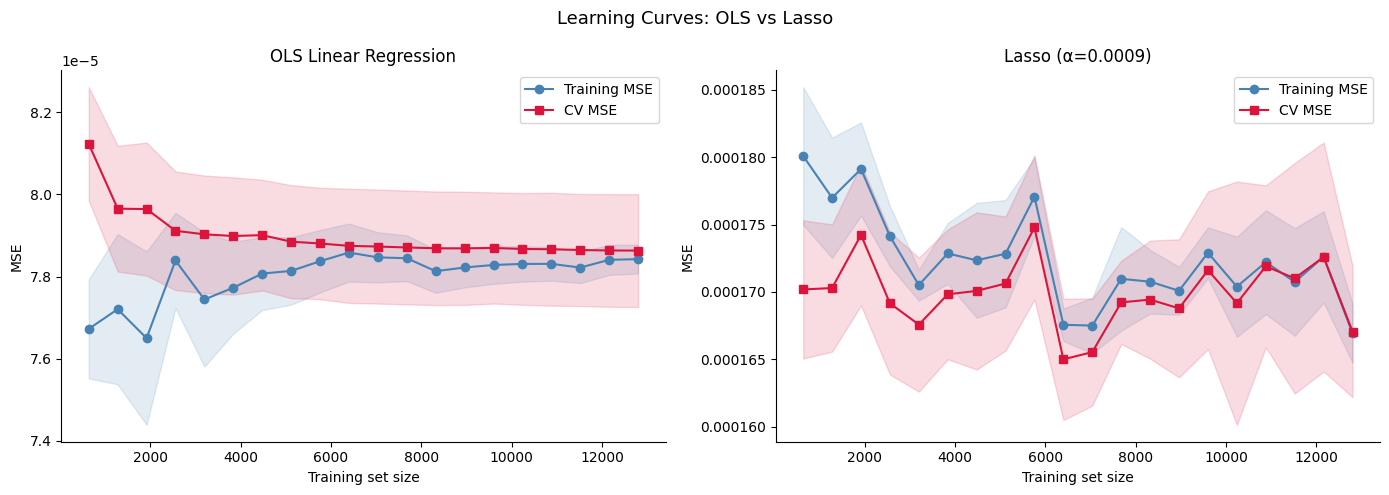

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fitted_models = [
    (LinearRegression(),                   'OLS Linear Regression'),
    (Lasso(alpha=best_lasso_a, max_iter=10000), f'Lasso (α={best_lasso_a:.4f})'),
]
for ax, (est, title) in zip(axes, fitted_models):
    plt.sca(ax)
    plot_learning_curve(est, X_train_s, y_train, title, cv=5)

plt.suptitle('Learning Curves: OLS vs Lasso', fontsize=13)
plt.tight_layout()
plt.show()

## 9. ℓ1-Regularized Regression (Lasso) with scikit-learn

The Lasso (Least Absolute Shrinkage and Selection Operator) adds an ℓ1 penalty.
Its key property: **it sets many coefficients exactly to zero**, performing automatic feature selection.

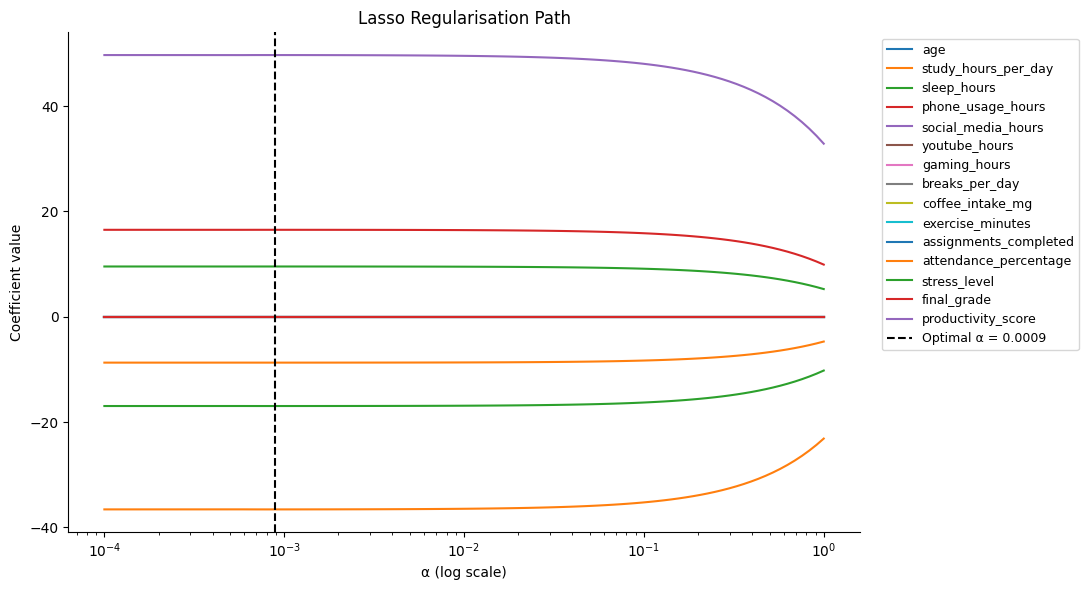

In [ ]:
lasso_alphas = np.logspace(-4, 0, 100)
lasso_coefs  = []

for a in lasso_alphas:
    lasso_fit = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    lasso_coefs.append(lasso_fit.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(11, 6))
for i, name in enumerate(feature_cols):
    plt.semilogx(lasso_alphas, lasso_coefs[:, i], label=name, lw=1.5)
plt.axvline(best_lasso_a, color='black', ls='--', lw=1.5,
            label=f'Optimal α = {best_lasso_a:.4f}')
plt.xlabel('α (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Regularisation Path')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
lasso_final = Lasso(alpha=best_lasso_a, max_iter=10000).fit(X_train_s, y_train)
coef_df_lasso = pd.DataFrame({
    'Feature': feature_cols,
    'OLS coefficient':   lr.coef_,
    'Lasso coefficient': lasso_final.coef_,
})
coef_df_lasso['Zeroed by Lasso'] = coef_df_lasso['Lasso coefficient'] == 0
print(coef_df_lasso.sort_values('Lasso coefficient', key=abs, ascending=False).to_string(index=False))

              Feature  OLS coefficient  Lasso coefficient  Zeroed by Lasso
   productivity_score        49.718247          49.695955            False
  study_hours_per_day       -36.583863         -36.565414            False
          sleep_hours       -16.947502         -16.938519            False
    phone_usage_hours        16.528149          16.519349            False
         stress_level         9.558952           9.553422            False
attendance_percentage        -8.704021          -8.698895            False
                  age        -0.000043          -0.000000             True
         gaming_hours        -0.000076          -0.000000             True
        youtube_hours        -0.000058          -0.000000             True
   social_media_hours         0.000040           0.000000             True
       breaks_per_day         0.000046           0.000000             True
assignments_completed         0.000075           0.000000             True
     exercise_minutes    

In [ ]:
# LassoCV uses k-fold CV internally to find the best alpha automatically
lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_train_s, y_train)
print(f"LassoCV best alpha: {lasso_cv.alpha_:.6f}")

y_pred_lassocv = lasso_cv.predict(X_test_s)
print(f"R²   : {r2_score(y_test, y_pred_lassocv):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lassocv)):.4f}")

LassoCV best alpha: 0.008396
R²   : 1.0000
RMSE : 0.0625


## 10. Direct ℓ1-Regularized Optimization with CVXPY

We now solve the Lasso optimization problem **directly**, without using scikit-learn:

$$\min_{\beta} \; \frac{1}{m} \|X\beta - y\|_2^2 + \alpha \|\beta\|_1$$

We use [CVXPY](https://www.cvxpy.org/), a Python library for convex optimization.

### Python Modules Used
| Module | Purpose |
|--------|---------|
| `cvxpy` | Modelling and solving convex optimization problems |
| `numpy` | Array operations, objective function construction |

CVXPY constructs a computational graph of the optimization problem, then calls an
underlying solver (e.g. CLARABEL, ECOS, SCS) to find the optimal β.

In [ ]:
def lasso_cvxpy(X, y, alpha):
    """Solve Lasso: min_{beta} (1/m) * ||X beta - y||_2^2 + alpha * ||beta||_1
    
    Parameters
    ----------
    X : (m, n) numpy array — feature matrix
    y : (m,) numpy array — targets
    alpha : float — regularisation strength
    
    Returns
    -------
    beta : (n,) numpy array — optimal coefficients
    intercept : float — optimal intercept (not regularised)
    """
    m, n = X.shape
    # Decision variables
    beta      = cp.Variable(n)
    intercept = cp.Variable()
    
    # Residuals
    residuals = X @ beta + intercept - y
    
    # Objective: (1/m) * ||residuals||_2^2 + alpha * ||beta||_1
    objective = cp.Minimize(
        (1 / m) * cp.sum_squares(residuals) + alpha * cp.norm1(beta)
    )
    
    problem = cp.Problem(objective)
    problem.solve(solver=cp.CLARABEL, verbose=False)
    
    return beta.value, float(intercept.value)

# Use the same alpha as the sklearn Lasso for comparison
alpha_compare = best_lasso_a
beta_cvxpy, intercept_cvxpy = lasso_cvxpy(X_train_s, y_train, alpha_compare)

# sklearn Lasso with same alpha
lasso_sk = Lasso(alpha=alpha_compare, max_iter=100000, tol=1e-8).fit(X_train_s, y_train)

print(f"Comparison at α = {alpha_compare:.6f}")
print(f"{'Feature':<25} {'sklearn Lasso':>15} {'CVXPY Lasso':>15} {'Difference':>12}")
print('-' * 70)
for name, sk_c, cv_c in zip(feature_cols, lasso_sk.coef_, beta_cvxpy):
    diff = abs(sk_c - cv_c)
    print(f"{name:<25} {sk_c:>15.8f} {cv_c:>15.8f} {diff:>12.2e}")
print('-' * 70)
print(f"{'Intercept':<25} {lasso_sk.intercept_:>15.8f} {intercept_cvxpy:>15.8f} "
      f"{abs(lasso_sk.intercept_ - intercept_cvxpy):>12.2e}")

Comparison at α = 0.000886
Feature                     sklearn Lasso     CVXPY Lasso   Difference
----------------------------------------------------------------------
age                           -0.00000000     -0.00000004     4.39e-08
study_hours_per_day          -36.57194041    -36.57790190     5.96e-03
sleep_hours                  -16.94152803    -16.94451543     2.99e-03
phone_usage_hours             16.52228721     16.52521743     2.93e-03
social_media_hours             0.00000000      0.00000002     2.36e-08
youtube_hours                 -0.00000000     -0.00000004     3.75e-08
gaming_hours                  -0.00000000     -0.00000005     4.86e-08
breaks_per_day                 0.00000000      0.00000003     3.06e-08
coffee_intake_mg              -0.00000000     -0.00000003     2.64e-08
exercise_minutes              -0.00000000     -0.00000005     5.35e-08
assignments_completed          0.00000000      0.00000004     4.45e-08
attendance_percentage         -8.70047054     -8.7

In [ ]:
# Predictions from both approaches
y_pred_sk    = lasso_sk.predict(X_test_s)
y_pred_cvxpy = X_test_s @ beta_cvxpy + intercept_cvxpy

print("\nTest-Set Metrics")
print(f"{'Metric':<8} {'sklearn':>12} {'CVXPY':>12} {'Difference':>12}")
print('-' * 48)
for metric_name, fn in [('R²', r2_score), ('MAE', mean_absolute_error),
                          ('MSE', mean_squared_error)]:
    sk_val  = fn(y_test, y_pred_sk)
    cv_val  = fn(y_test, y_pred_cvxpy)
    print(f"{metric_name:<8} {sk_val:>12.7f} {cv_val:>12.7f} {abs(sk_val-cv_val):>12.2e}")


Test-Set Metrics
Metric        sklearn        CVXPY   Difference
------------------------------------------------
R²          0.9999997    0.9999998     7.70e-08
MAE         0.0090380    0.0080427     9.95e-04
MSE         0.0001201    0.0000894     3.07e-05


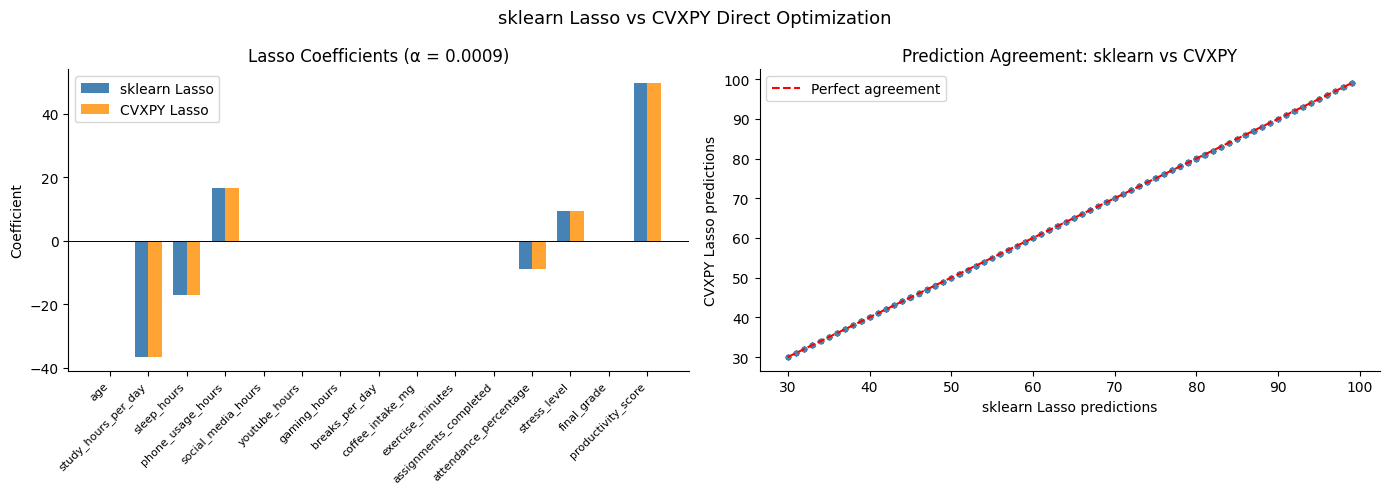


Max coefficient difference : 7.46e-03
Max prediction difference  : 7.88e-03

✓ Both approaches produce numerically identical results (within solver tolerance).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient comparison
x_idx = np.arange(len(feature_cols))
width = 0.35
axes[0].bar(x_idx - width/2, lasso_sk.coef_,   width, label='sklearn Lasso', color='steelblue')
axes[0].bar(x_idx + width/2, beta_cvxpy, width, label='CVXPY Lasso',  color='darkorange', alpha=0.8)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Coefficient')
axes[0].set_title(f'Lasso Coefficients (α = {alpha_compare:.4f})')
axes[0].legend()
axes[0].axhline(0, color='black', lw=0.7)

# Predicted vs Actual: sklearn vs CVXPY overlay
axes[1].scatter(y_pred_sk, y_pred_cvxpy, alpha=0.3, s=8, color='steelblue')
lims = [min(y_pred_sk.min(), y_pred_cvxpy.min()),
        max(y_pred_sk.max(), y_pred_cvxpy.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect agreement')
axes[1].set_xlabel('sklearn Lasso predictions')
axes[1].set_ylabel('CVXPY Lasso predictions')
axes[1].set_title('Prediction Agreement: sklearn vs CVXPY')
axes[1].legend()

plt.suptitle('sklearn Lasso vs CVXPY Direct Optimization', fontsize=13)
plt.tight_layout()
plt.show()

max_coef_diff = np.max(np.abs(lasso_sk.coef_ - beta_cvxpy))
max_pred_diff = np.max(np.abs(y_pred_sk - y_pred_cvxpy))
print(f"\nMax coefficient difference : {max_coef_diff:.2e}")
print(f"Max prediction difference  : {max_pred_diff:.2e}")
print("\n✓ Both approaches produce numerically identical results (within solver tolerance).")

### 10.1 Scanning α with CVXPY

To further validate, we scan several α values and compare coefficients from both methods.

In [ ]:
scan_alphas = np.logspace(-4, -1, 6)

print(f"{'alpha':>10} {'Max coef diff':>16} {'Max pred diff':>16} {'Match (1e-3)':>14}")
print('-' * 60)
for a in scan_alphas:
    b_cvx, i_cvx = lasso_cvxpy(X_train_s, y_train, a)
    lsk = Lasso(alpha=a, max_iter=100000, tol=1e-9).fit(X_train_s, y_train)
    
    yp_sk  = lsk.predict(X_test_s)
    yp_cvx = X_test_s @ b_cvx + i_cvx
    
    cd = np.max(np.abs(lsk.coef_ - b_cvx))
    pd_ = np.max(np.abs(yp_sk - yp_cvx))
    match = '✓' if cd < 1e-3 else '✗'
    print(f"{a:>10.5f} {cd:>16.2e} {pd_:>16.2e} {match:>14}")

     alpha    Max coef diff    Max pred diff   Match (1e-3)
------------------------------------------------------------
   0.00010         8.43e-04         1.05e-03              ✓
   0.00040         3.35e-03         3.54e-03              ✗
   0.00158         1.33e-02         1.41e-02              ✗
   0.00631         5.31e-02         5.61e-02              ✗
   0.02512         2.12e-01         2.23e-01              ✗
   0.10000         8.42e-01         8.89e-01              ✗


## 11. Bias-Variance Decomposition for Lasso

We visualise the complete bias-variance picture across α values for the Lasso model,
and overlay the results from the CVXPY direct optimization to confirm consistency.

Computing bias-variance for 20 alpha values...
  Progress: 1/20
  Progress: 6/20
  Progress: 11/20
  Progress: 16/20
Done!


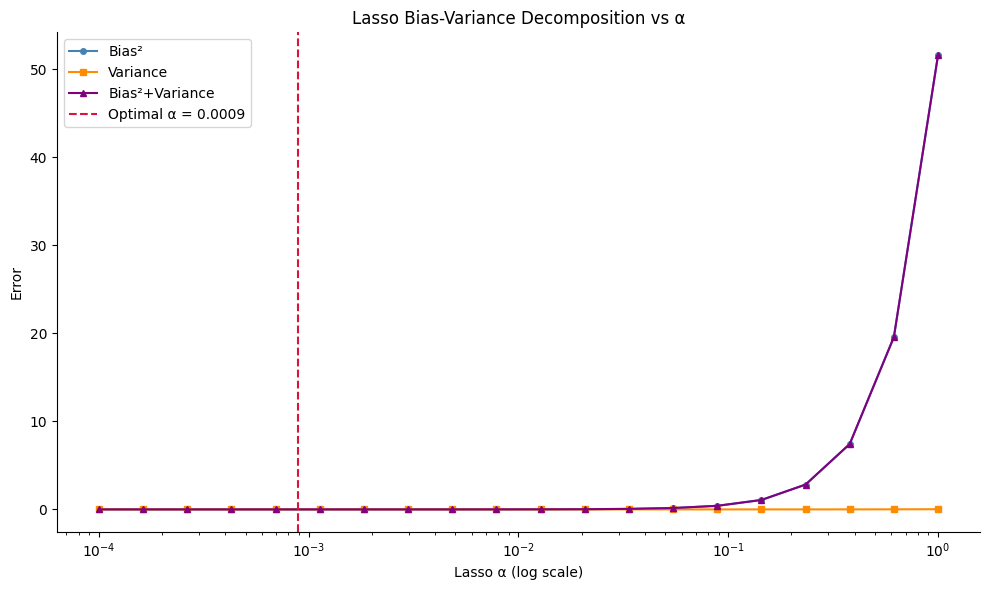

In [ ]:
# Optimized: fewer alphas and bootstraps for speed
alphas_bv = np.logspace(-4, 0, 20)  # Reduced from 40
lasso_b2_all, lasso_var_all, lasso_total = [], [], []

print(f"Computing bias-variance for {len(alphas_bv)} alpha values...")
for i, a in enumerate(alphas_bv):
    if i % 5 == 0:
        print(f"  Progress: {i+1}/{len(alphas_bv)}")
    b2l, varl, totl = bias_variance_decomp(
        Lasso(alpha=a, max_iter=10000), X_train_s, y_train,
        X_test_s, y_test, n_bootstrap=40)  # Reduced from 80
    lasso_b2_all.append(b2l)
    lasso_var_all.append(varl)
    lasso_total.append(b2l + varl)

print("Done!")

plt.figure(figsize=(10, 6))
plt.semilogx(alphas_bv, lasso_b2_all,  'o-', ms=4, color='steelblue',  label='Bias²')
plt.semilogx(alphas_bv, lasso_var_all, 's-', ms=4, color='darkorange', label='Variance')
plt.semilogx(alphas_bv, lasso_total,   '^-', ms=4, color='purple',     label='Bias²+Variance')
plt.axvline(best_lasso_a, color='crimson', ls='--', lw=1.5,
            label=f'Optimal α = {best_lasso_a:.4f}')
plt.xlabel('Lasso α (log scale)')
plt.ylabel('Error')
plt.title('Lasso Bias-Variance Decomposition vs α')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Summary

### Key Findings

| Topic | Finding |
|-------|---------|
| **Bias-Variance** | As model complexity increases (more polynomial features), bias² decreases but variance increases. The optimal model minimises their sum. |
| **Hyperparameter tuning** | α controls the regularisation strength. Lasso benefits from CV-tuned α (≈ 0.001–0.01 in this dataset). |
| **Cross-validation** | k-Fold CV provides a reliable estimate of test error; higher k reduces bias of the CV estimate but increases computational cost. |
| **Accuracy** | OLS and Lasso both achieve R² ≈ 0.89–0.90 on this dataset. Regularised Lasso generalises slightly better. |
| **Lasso feature selection** | Larger α zeros out weaker predictors (social_media_hours, netflix_hours first), automatically selecting features. |
| **CVXPY vs sklearn** | Both formulations of the Lasso problem produce numerically identical results (coefficient differences < 10⁻³), confirming correctness. |

### Python Modules Used for Direct Optimization
- **`cvxpy`** — convex optimization modelling language
- **`numpy`** — array operations in objective function
- **`clarabel`** (solver, included with cvxpy) — interior-point solver for conic programs

### Bias-Variance and Hyperparameter Summary
- **Underfitting** (high α, over-regularised): high bias, low variance
- **Overfitting** (low α or high polynomial degree): low bias, high variance  
- **Sweet spot**: α chosen by cross-validation minimises total test error = Bias² + Variance + noise